In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [2]:
from pyexcel_ods3 import get_data
import json

In [3]:
def read_ods_as_nested_dict(filename):

    data = get_data(filename)
    sheet_data = data['Sheet1']
    
    # FIXED: Strip spaces from headers
    headers = [header.strip() if isinstance(header, str) else header 
               for header in sheet_data[0][1:]]  # Skip first empty header
    
    result = {}
    current_operation = None
    
    for row in sheet_data[1:]:
        if not row or all(x is None or x == '' for x in row):
            continue
            
        if row[0] is not None and row[0] != '':
            current_operation = row[0]
        
        if current_operation not in result:
            result[current_operation] = {}
        
        # Get vector length and block size
        vector_length = row[1] if len(row) > 1 else None
        block_size = row[2] if len(row) > 2 else None
        
        if vector_length not in result[current_operation]:
            result[current_operation][vector_length] = {}
        
        # Store all metrics for this combination
        metrics = {}
        for i, header in enumerate(headers[2:], 3):  # Skip vector_length and block_size
            if i < len(row):
                # FIXED: Use stripped header as key
                metrics[header] = row[i]
        
        result[current_operation][vector_length][block_size] = metrics
    
    return result

In [4]:
agner_pmc_haswell = read_ods_as_nested_dict('../measurement/agner_measurement_table_haswell_Vec8f.ods')
agner_pmc_skylake = read_ods_as_nested_dict('../measurement/agner_measurement_table_skylake_Vec8f.ods')
agner_pmc_meteorlake = read_ods_as_nested_dict('../measurement/agner_measurement_table_meteorlake_Vec8f.ods')

In [5]:
agner_pmc_haswell.keys()

dict_keys(['permute', 'depermute', 'fir cores', 'part sol', 'homo sol', 'cr forward', 'cr backward', 'iir ph', 'iir cr', 'block filtering', 'scalar', 'filter ph 2', 'filter ph 4', 'filter ph 8', 'filter ph 16', 'filter cr 2', 'filter cr 4', 'filter cr 8', 'filter cr 16', 'filter bf 2', 'filter bf 4', 'filter bf 8', 'filter bf 16', 'filter sc 2', 'filter sc 4', 'filter sc 8', 'filter sc 16'])

In [6]:
agner_pmc_haswell['permute'][8][8]
agner_pmc_haswell['permute'][4][16]

{'data size': 64,
 'cyc': 42,
 'inst': 82,
 'uops': 99,
 'rs': 0,
 'rs std': 0,
 'cm': 0,
 'cm std': 0,
 'cdm': 0,
 'cdm std': 0,
 'cps': 0.65625,
 'ips': 1.28125,
 'ipc': 1.9523809523809523,
 'rss': 0}

In [7]:
pm_pmc_haswell = agner_pmc_haswell['permute'][8]

pm_cps_haswell = np.array([metrics['cps'] for metrics in pm_pmc_haswell.values()])
pm_ipc_haswell = np.array([metrics['ipc'] for metrics in pm_pmc_haswell.values()])

In [8]:
pm_pmc_skylake = agner_pmc_skylake['permute'][8]

pm_cps_skylake = np.array([metrics['cps'] for metrics in pm_pmc_skylake.values()])
pm_ipc_skylake = np.array([metrics['ipc'] for metrics in pm_pmc_skylake.values()])

In [9]:
pm_pmc_meteorlake = agner_pmc_meteorlake['permute'][8]

pm_cps_meteorlake = np.array([metrics['cps'] for metrics in pm_pmc_meteorlake.values()])
pm_ipc_meteorlake = np.array([metrics['ipc'] for metrics in pm_pmc_meteorlake.values()])

In [10]:
ps_pmc_haswell = agner_pmc_haswell['part sol'][8]

ps_cps_haswell = np.array([metrics['cps'] for metrics in ps_pmc_haswell.values()])
ps_ipc_haswell = np.array([metrics['ipc'] for metrics in ps_pmc_haswell.values()])

In [11]:
ps_pmc_skylake = agner_pmc_skylake['part sol'][8]

ps_cps_skylake = np.array([metrics['cps'] for metrics in ps_pmc_skylake.values()])
ps_ipc_skylake = np.array([metrics['ipc'] for metrics in ps_pmc_skylake.values()])

In [12]:
ps_pmc_meteorlake = agner_pmc_meteorlake['part sol'][8]

ps_cps_meteorlake = np.array([metrics['cps'] for metrics in ps_pmc_meteorlake.values()])
ps_ipc_meteorlake = np.array([metrics['ipc'] for metrics in ps_pmc_meteorlake.values()])

In [13]:
fir_pmc_haswell = agner_pmc_haswell['fir cores'][8]

fir_cps_haswell = np.array([metrics['cps'] for metrics in fir_pmc_haswell.values()])
fir_ipc_haswell = np.array([metrics['ipc'] for metrics in fir_pmc_haswell.values()])

In [14]:
fir_pmc_skylake = agner_pmc_skylake['fir cores'][8]

fir_cps_skylake = np.array([metrics['cps'] for metrics in fir_pmc_skylake.values()])
fir_ipc_skylake = np.array([metrics['ipc'] for metrics in fir_pmc_skylake.values()])

In [15]:
fir_pmc_meteorlake = agner_pmc_meteorlake['fir cores'][8]

fir_cps_meteorlake = np.array([metrics['cps'] for metrics in fir_pmc_meteorlake.values()])
fir_ipc_meteorlake = np.array([metrics['ipc'] for metrics in fir_pmc_meteorlake.values()])

In [16]:
crf_pmc_haswell = agner_pmc_haswell['cr forward'][8]

crf_cps_haswell = np.array([metrics['cps'] for metrics in crf_pmc_haswell.values()])
crf_ipc_haswell = np.array([metrics['ipc'] for metrics in crf_pmc_haswell.values()])

In [17]:
crf_pmc_skylake = agner_pmc_skylake['cr forward'][8]

crf_cps_skylake = np.array([metrics['cps'] for metrics in crf_pmc_skylake.values()])
crf_ipc_skylake = np.array([metrics['ipc'] for metrics in crf_pmc_skylake.values()])

In [18]:
crf_pmc_meteorlake = agner_pmc_meteorlake['cr forward'][8]

crf_cps_meteorlake = np.array([metrics['cps'] for metrics in crf_pmc_meteorlake.values()])
crf_ipc_meteorlake = np.array([metrics['ipc'] for metrics in crf_pmc_meteorlake.values()])

In [19]:
crb_pmc_haswell = agner_pmc_haswell['cr backward'][8]

crb_cps_haswell = np.array([metrics['cps'] for metrics in crb_pmc_haswell.values()])
crb_ipc_haswell = np.array([metrics['ipc'] for metrics in crb_pmc_haswell.values()])

In [20]:
crb_pmc_skylake = agner_pmc_skylake['cr backward'][8]

crb_cps_skylake = np.array([metrics['cps'] for metrics in crb_pmc_skylake.values()])
crb_ipc_skylake = np.array([metrics['ipc'] for metrics in crb_pmc_skylake.values()])

In [21]:
crb_pmc_meteorlake = agner_pmc_meteorlake['cr backward'][8]

crb_cps_meteorlake = np.array([metrics['cps'] for metrics in crb_pmc_meteorlake.values()])
crb_ipc_meteorlake = np.array([metrics['ipc'] for metrics in crb_pmc_meteorlake.values()])

In [22]:
hs_pmc_haswell = agner_pmc_haswell['homo sol'][8]

hs_cps_haswell = np.array([metrics['cps'] for metrics in hs_pmc_haswell.values()])
hs_ipc_haswell = np.array([metrics['ipc'] for metrics in hs_pmc_haswell.values()])

In [23]:
hs_pmc_skylake = agner_pmc_skylake['homo sol'][8]

hs_cps_skylake = np.array([metrics['cps'] for metrics in hs_pmc_skylake.values()])
hs_ipc_skylake = np.array([metrics['ipc'] for metrics in hs_pmc_skylake.values()])

In [24]:
hs_pmc_meteorlake = agner_pmc_meteorlake['homo sol'][8]

hs_cps_meteorlake = np.array([metrics['cps'] for metrics in hs_pmc_meteorlake.values()])
hs_ipc_meteorlake = np.array([metrics['ipc'] for metrics in hs_pmc_meteorlake.values()])

In [25]:
L = 8
N = 2**np.arange(3,9)
N

array([  8,  16,  32,  64, 128, 256])

In [26]:
N = np.array([64,128,256,512,1024,2048])

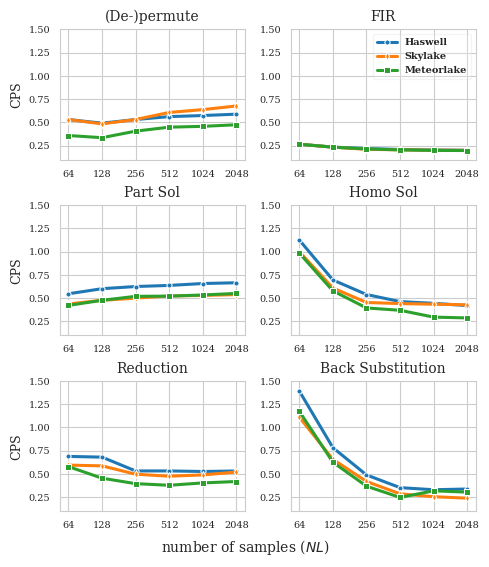

In [27]:
# Set seaborn style and font properties
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.labelsize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 8
})

default_palette = sns.color_palette()
blue = default_palette[0]    # Default blue (first color)
orange = default_palette[1]  # Default orange (second color)
green = default_palette[2]   # Default green (third color)
red = default_palette[3]     # Default red (fourth color)

# Create 2x3 subplot layout
# fig, axes = plt.subplots(2, 3, figsize=(9, 4.5))
fig, axes = plt.subplots(3, 2, figsize=(5, 5.5))  # <-- changed from (2,3)
axes = axes.flatten()  # Flatten to make indexing easier
N_ticks = np.arange(len(N))

# Define colors for each architecture
colors = {'haswell': blue, 'skylake': red, 'meteorlake': orange}

# Data structure for easier iteration
operations = [
    ('(De-)permute', pm_cps_haswell, pm_cps_skylake, pm_cps_meteorlake, pm_ipc_haswell, pm_ipc_skylake, pm_ipc_meteorlake),
    ('FIR', fir_cps_haswell, fir_cps_skylake, fir_cps_meteorlake, fir_ipc_haswell, fir_ipc_skylake, fir_ipc_meteorlake),
    ('Part Sol', ps_cps_haswell, ps_cps_skylake, ps_cps_meteorlake, ps_ipc_haswell, ps_ipc_skylake, ps_ipc_meteorlake),
    ('Homo Sol', hs_cps_haswell, hs_cps_skylake, hs_cps_meteorlake, hs_ipc_haswell, hs_ipc_skylake, hs_ipc_meteorlake),
    ('Reduction', crf_cps_haswell, crf_cps_skylake, crf_cps_meteorlake, crf_ipc_haswell, crf_ipc_skylake, crf_ipc_meteorlake),
    ('Back Substitution', crb_cps_haswell, crb_cps_skylake, crb_cps_meteorlake, crb_ipc_haswell, crb_ipc_skylake, crb_ipc_meteorlake)
]

# Create plots for each operation
for i, (op_name, cps_haswell, cps_skylake, cps_meteorlake, ipc_haswell, ipc_skylake, ipc_meteorlake) in enumerate(operations):
    ax = axes[i]

    # CPS data (solid lines) using seaborn
    sns.lineplot(x=N_ticks, y=cps_haswell[:-1], marker='o', label='Haswell', 
                linewidth=2.2, color=blue, linestyle='-', ax=ax, markersize=3.7)
    sns.lineplot(x=N_ticks, y=cps_skylake[:-1], marker='d', label='Skylake', 
                linewidth=2.2, color=orange, linestyle='-', ax=ax, markersize=3.7)
    sns.lineplot(x=N_ticks, y=cps_meteorlake, marker='s', label='Meteorlake', 
                linewidth=2.2, color=green, linestyle='-', ax=ax, markersize=3.7)
    
    # # IPC data (dashed lines) using seaborn
    # sns.lineplot(x=N_ticks, y=ipc_haswell[:-1], marker='o', label='Haswell IPC', 
    #             linewidth=2.1, color=blue, linestyle='--', ax=ax, markersize=3.7)
    # sns.lineplot(x=N_ticks, y=ipc_skylake[:-1], marker='d', label='Skylake IPC', 
    #             linewidth=2.1, color=orange, linestyle='--', ax=ax, markersize=3.7)
    # sns.lineplot(x=N_ticks, y=ipc_meteorlake, marker='s', label='Meteor IPC', 
    #             linewidth=2.1, color=green, linestyle='--', ax=ax, markersize=3.7)
    
    # Configure axes
    ax.set_xticks(N_ticks)
    ax.set_xticklabels(N)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Add subtitle for each subplot
    ax.set_title(op_name, fontsize=10)
    
    # Create legend ONLY for first row, third plot (index 2)
    if i == 1:
        legend = ax.legend(framealpha=0.9, fontsize=7, loc='upper right')
        legend.get_frame().set_alpha(0.2)
        for text in legend.get_texts():
            text.set_fontweight('bold')
    else:
        # Remove legend from all other subplots
        ax.legend().set_visible(False)

    if i == 0:
        ax.set_ylabel('CPS')
    if i == 2:
        ax.set_ylabel('CPS')
    if i == 4:
        ax.set_ylabel('CPS')

    # if i == 3:
    #     handles, labels = ax.get_legend_handles_labels()
    #     legend = ax.legend(
    #         handles, labels,
    #         ncol=2,                 # 🔹 two-sided / two-column legend
    #         fontsize=6,             # 🔹 smaller legend font
    #         framealpha=0.9,
    #         loc='upper center',
    #         bbox_to_anchor=(0.5, -0.15)  # move legend slightly below the axes
    #     )
    #     legend.get_frame().set_alpha(0.2)
    #     for text in legend.get_texts():
    #         text.set_fontweight('bold')
    # else:
    #     ax.legend().set_visible(False)


# Collect all CPS data used in the plots
all_cps_arrays = [
    pm_cps_haswell[:-1], pm_cps_skylake[:-1], pm_cps_meteorlake,
    fir_cps_haswell[:-1], fir_cps_skylake[:-1], fir_cps_meteorlake,
    ps_cps_haswell[:-1], ps_cps_skylake[:-1], ps_cps_meteorlake,
    hs_cps_haswell[:-1], hs_cps_skylake[:-1], hs_cps_meteorlake,
    crf_cps_haswell[:-1], crf_cps_skylake[:-1], crf_cps_meteorlake,
    crb_cps_haswell[:-1], crb_cps_skylake[:-1], crb_cps_meteorlake,
]

y_min = min(np.min(a) for a in all_cps_arrays)
y_max = max(np.max(a) for a in all_cps_arrays)

# Apply same y-limits to all subplots
for ax in axes:
    ax.set_ylim(0.1, 1.5)


plt.tight_layout()
plt.subplots_adjust(wspace=0.25, hspace=0.35)  # Added hspace for subtitle spacing
# fig.text(0.5, -0.02, 'Function Size (NL)', ha='center', va='bottom', fontsize=11)
# # Common title for column 1 (Performance Rate)
# fig.text(0.5, 1, 'Pipeline Efficiency vs. Clock Rate', ha='center', va='bottom', 
#          fontsize=10)

fig.text(0.5, -0.005, 'number of samples ($NL$)', ha='center', va='center', fontsize=10)
# plt.savefig('plot2.jpg', bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none')
plt.show()